In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [ ]:
manual_path = ""

file_names = [
    "student_performance_final.csv",
    "student_performance_cleaned.csv.csv",
    "student_performance_cleaned.csv",
]

folders = [
    Path("."),
    Path(".."),
    Path("../.."),
    Path("dataset/processed"),
    Path("../dataset/processed"),
    Path("../../dataset/processed"),
    Path(r"D:\adaptive-quiz-system\dataset\processed"),
    Path("/content"),
]

dataset_path = Path(manual_path) if manual_path else None

if dataset_path is None:
    for name in file_names:
        for folder in folders:
            if (folder / name).exists():
                dataset_path = folder / name
                break
        if dataset_path is not None:
            break

if dataset_path is None or not dataset_path.exists():
    raise FileNotFoundError(
        "Dataset file not found. Keep the CSV near this notebook or write its full path in manual_path"
    )

df = pd.read_csv(dataset_path)
print("Dataset loaded:", dataset_path)
print("Shape:", df.shape)

Dataset loaded: D:\adaptive-quiz-system\dataset\processed\student_performance_final.csv
Shape: (2392, 15)


In [ ]:
required_columns = ["StudentID", "Age", "StudyTimeWeekly", "Absences", "GPA", "GradeClass"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}. Available columns: {list(df.columns)}")

df = df.drop_duplicates()
df = df.dropna()
df["GradeClass"] = df["GradeClass"].astype(int)
df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2392, 15)


In [ ]:
df["GradeClass"].value_counts().sort_index()

GradeClass
0     107
1     269
2     391
3     414
4    1211
Name: count, dtype: int64

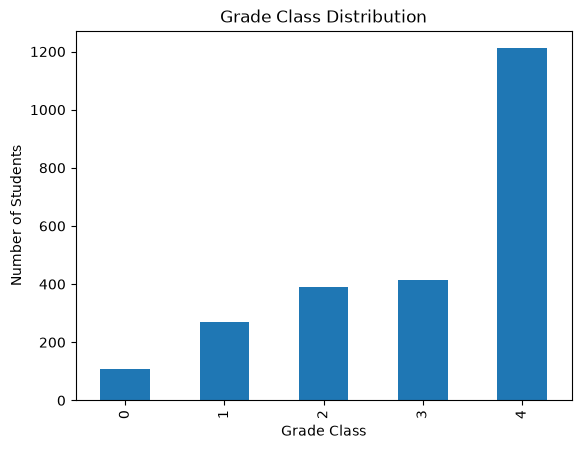

In [ ]:
df["GradeClass"].value_counts().sort_index().plot(kind="bar")

plt.title("Grade Class Distribution")
plt.xlabel("Grade Class")
plt.ylabel("Number of Students")
plt.show()

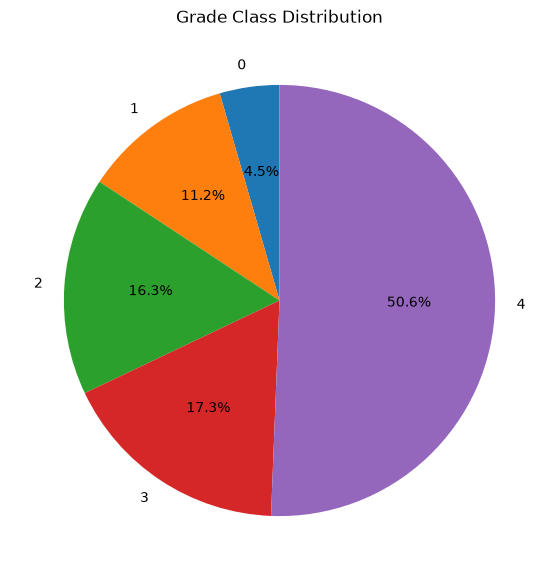

In [ ]:
grade_counts = df["GradeClass"].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(grade_counts, labels=grade_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Grade Class Distribution")
plt.show()

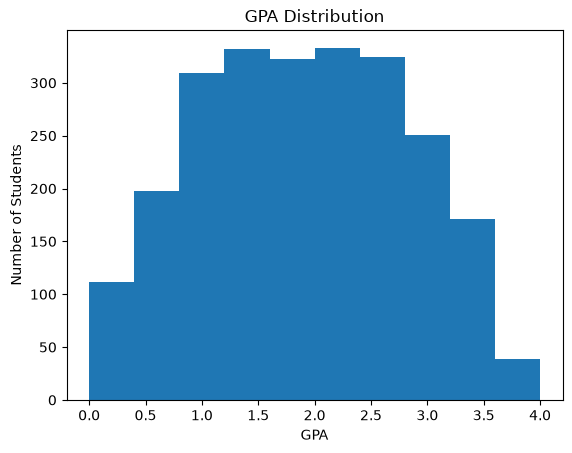

In [ ]:
plt.hist(df["GPA"], bins=10)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.show()

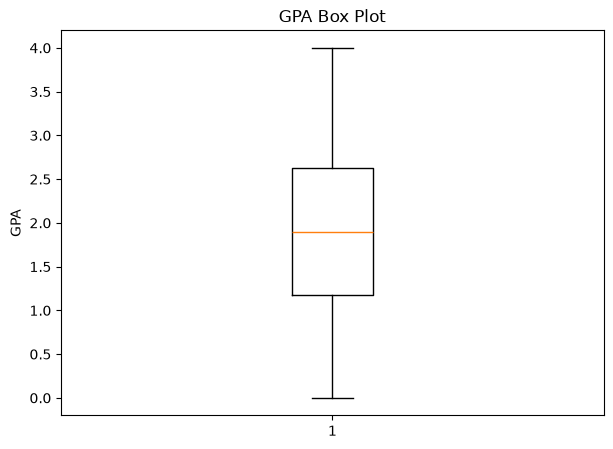

In [ ]:
plt.figure(figsize=(7, 5))
plt.boxplot(df["GPA"])

plt.title("GPA Box Plot")
plt.ylabel("GPA")
plt.show()

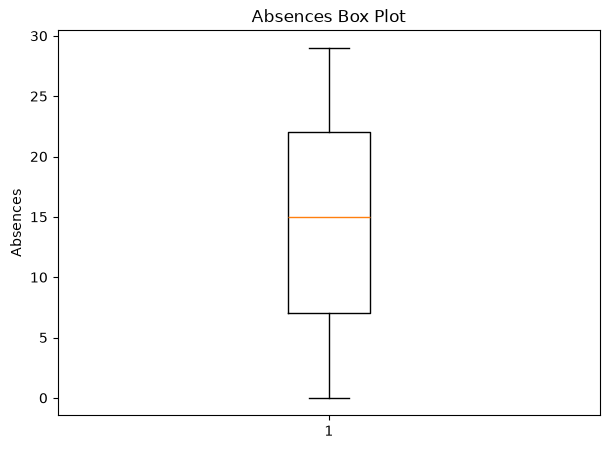

In [ ]:
plt.figure(figsize=(7, 5))
plt.boxplot(df["Absences"])

plt.title("Absences Box Plot")
plt.ylabel("Absences")
plt.show()

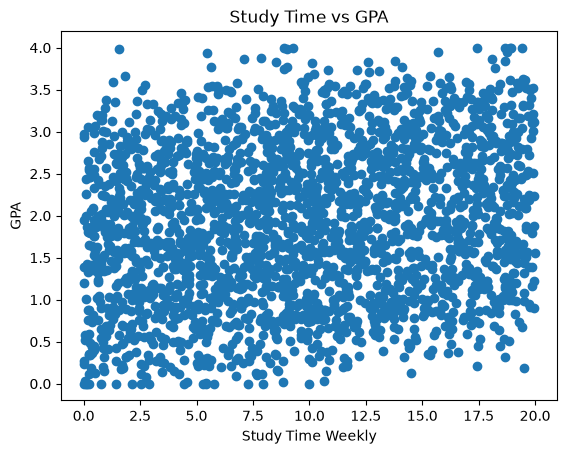

In [ ]:
plt.scatter(df["StudyTimeWeekly"], df["GPA"])

plt.title("Study Time vs GPA")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.show()

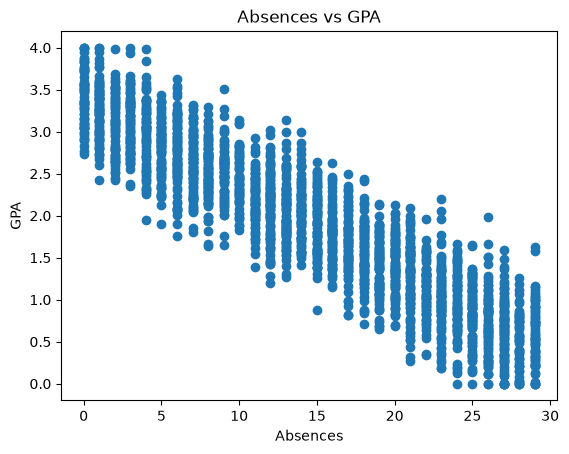

In [ ]:
plt.scatter(df["Absences"], df["GPA"])

plt.title("Absences vs GPA")
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

### Correlation Heatmap

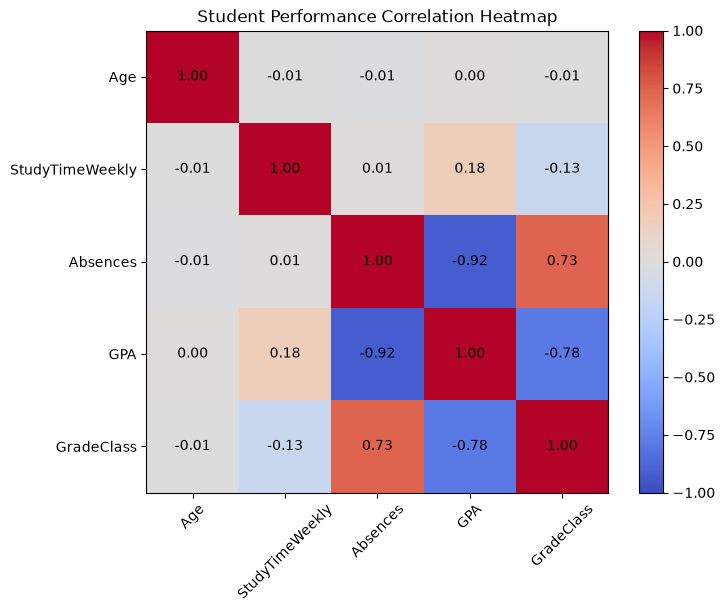

In [ ]:
numeric_columns = ["Age", "StudyTimeWeekly", "Absences", "GPA", "GradeClass"]
correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=45)
plt.yticks(range(len(numeric_columns)), numeric_columns)

for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Student Performance Correlation Heatmap")
plt.show()

In [ ]:
df.select_dtypes(include="number").corr()["GPA"].sort_values(ascending=False)

GPA                  1.000000
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
Absences            -0.919314
Name: GPA, dtype: float64

## 5. Clustering

In [ ]:
cluster_features = ["StudyTimeWeekly", "Absences", "GPA"]
scaled_features = StandardScaler().fit_transform(df[cluster_features])

print(scaled_features[:5])

[[ 1.78033552 -0.89082237  1.11808631]
 [ 0.99737625 -1.71769358  1.24237446]
 [-0.98404514  1.35354235 -1.96027719]
 [ 0.04544517 -0.06395116  0.1617897 ]
 [-0.90231145  0.29042222 -0.67557279]]


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)

df_clustered = df.copy()
df_clustered["Cluster"] = kmeans.fit_predict(scaled_features)

df_clustered[["StudentID", "StudyTimeWeekly", "Absences", "GPA", "Cluster"]].head(10)

,StudentID,StudyTimeWeekly,Absences,GPA,Cluster
0,1001,19.833723,7,2.929196,1
1,1002,15.408756,0,3.042915,1
2,1003,4.210570,26,0.112602,2
3,1004,10.028829,14,2.054218,1
4,1005,4.672495,17,1.288061,2
5,1006,8.191219,0,3.084184,1
6,1007,15.601680,10,2.748237,1
7,1008,15.424496,22,1.360143,0
8,1009,4.562008,1,2.896819,1
9,1010,18.444466,0,3.573474,1


### Cluster Plot

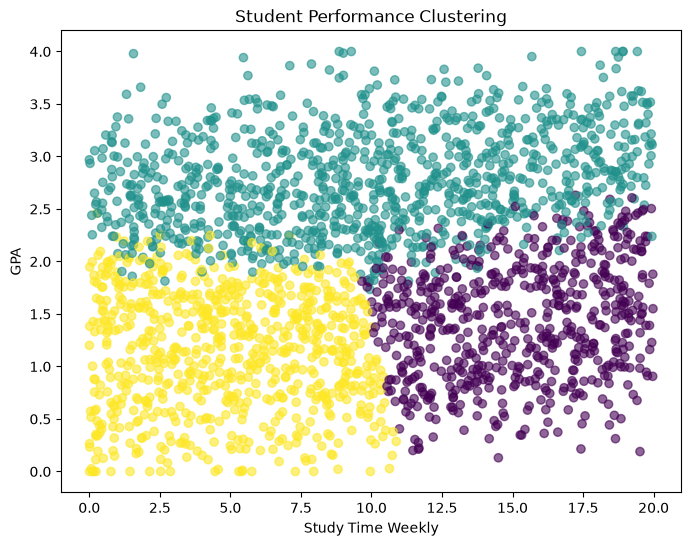

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clustered["StudyTimeWeekly"], df_clustered["GPA"],
            c=df_clustered["Cluster"], alpha=0.6)

plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.title("Student Performance Clustering")
plt.show()